In [1]:
from metasyn import demo_data, MetaFrame
from metasyn.builder import MetaFrameBuilder
from metasyn.privacy import BasicPrivacy
import numpy as np
import polars as pl
from matplotlib import pyplot as plt
from metasyn.distribution import ContinuousNormalDistribution, ContinuousUniformDistribution, ContinuousConstantDistribution
from metasyn.distribution.base import ColumnReference

In [2]:
def plot_dataframe(df):
    plt.scatter(df["base"], df["correlated"], label="correlated")
    plt.scatter(df["base"], df["larger"], label="larger")
    plt.plot(df["base"], df["base"], label="base")
    plt.scatter(df["base"], df["linear"], label="linear")
    plt.legend()
    plt.show()

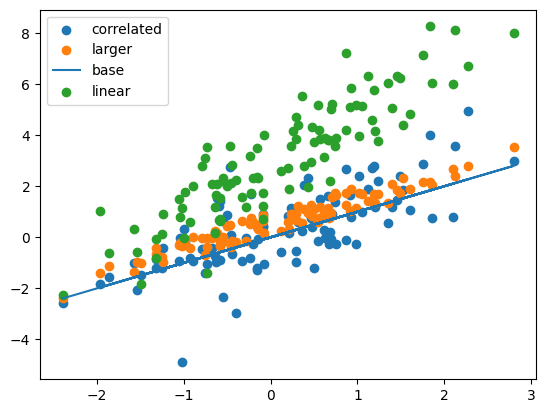

In [3]:
base = np.random.randn(100)
corr = np.random.randn(100) + base
constrained = np.random.rand(100) + base
linear = 3+2*base + np.random.randn(100)
df = pl.DataFrame({"base": base, "correlated": corr, "larger": constrained, "linear": linear})
plot_dataframe(df)


In [8]:
builder = MetaFrameBuilder()
builder.privacy = BasicPrivacy()
builder.add_column("base")
builder["base"].distribution = ContinuousNormalDistribution(0, 1)
builder.add_column("correlated")
builder["correlated"].distribution = ColumnReference("base") + ContinuousNormalDistribution(0, 1)
builder.add_column("larger")
builder["larger"].distribution = ColumnReference("base") + ContinuousUniformDistribution(0, 1)
builder.add_column("linear")
builder["linear"].distribution = ContinuousConstantDistribution(3.0) + ContinuousConstantDistribution(2)*ColumnReference("base") + ContinuousNormalDistribution(0, 1)
mf = builder.fit()

100%|██████████| 4/4 [00:00<00:00, 17494.49it/s]


      linear: 100%|██████████| 4/4 [00:00<00:00, 1125.53variables/s]


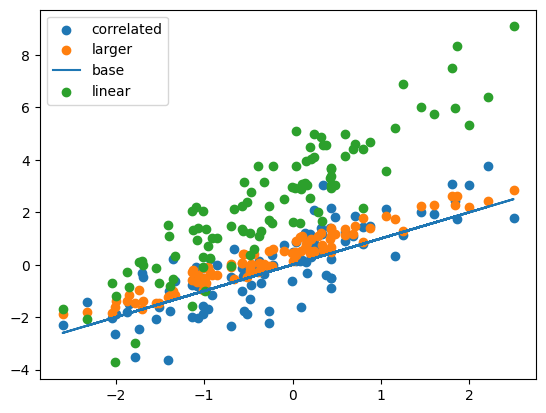

In [9]:
df_syn = mf.synthesize(100)
plot_dataframe(df_syn)